# 1. Quick start

Find and inspect open SAR scenes from **ICEYE**, **Umbra** and **Capella**.

```bash
pip install open-sar-triad          # core: no dependencies at all
pip install 'open-sar-triad[plot]'  # adds matplotlib for the maps below
```

No API key, no account. The backend is a static catalog on a CDN, so there is
nothing to authenticate against and nothing to rate limit.

In [1]:
# Point at the hosted API, or a local build for testing.
#   BASE = 'http://localhost:8000/api/v1'   # after: python3 -m http.server 8000
BASE = None

from opensartriad import Catalog

cat = Catalog(BASE) if BASE else Catalog()
cat

Catalog('https://www.pmuguda.com/open-sar-triad/api/v1')

## What is in the catalog?

`stats()` is a small file describing the whole collection. Cheap to call.

In [2]:
stats = cat.stats()

print('total scenes :', stats['total'])
print('by provider  :', stats['by_provider'])
print('date range   :', stats['temporal_extent'])
print('last built   :', stats['generated'][:10])

total scenes : 14859
by provider  : {'umbra': 11895, 'capella': 2464, 'iceye': 500}
date range   : ['2021-01-16', '2026-09-03']
last built   : 2026-09-22


In [3]:
# Sensor modes and formats actually present
print('modes  :', stats['by_mode'])
print('formats:', stats['by_format'])

modes  : {'spotlight': 14195, 'stripmap': 385, 'sliding_spotlight': 258, 'scan': 21}
formats: {'SICD': 13410, 'GEC': 13409, 'SIDD': 13116, 'CPHD': 13078, 'CSI': 12231, 'SLC': 2764, 'GEO': 2287, 'GRD': 500, 'VID': 324}


## A first search

All filters combine with AND. The bbox is `(west, south, east, north)` in EPSG:4326.

The first search downloads a ~0.6 MB index and caches it, so **reuse one `Catalog`**
and later searches are instant and entirely local.

In [4]:
scenes = cat.search(
    bbox=(5.9, 47.2, 10.5, 55.1),   # roughly Germany
    start='2025-01-01',
    end='2026-01-01',
)
scenes

SceneCollection(92 scenes; umbra 91, iceye 1; 2025-01-30 to 2025-12-23)

In [5]:
# SceneCollection behaves like a list
print(len(scenes))
for s in scenes[:5]:
    print(f'{s.date}  {s.provider:8} {s.mode or "?":10} {s.id[:46]}')

92
2025-11-09  iceye    spotlight  ICEYE_U1J05X_20251109T212114Z_6992608_X42_SLP3
2025-11-19  umbra    spotlight  1ac9045f-c63e-4621-a876-af321d6433a8
2025-04-11  umbra    spotlight  126a641f-f19d-406d-906e-11086c9d6fc2
2025-02-02  umbra    spotlight  ce31e5a7-6b8d-4608-ab54-8680976eb568
2025-02-20  umbra    spotlight  3f25a93b-1296-490c-92a7-5fd54d7cbd1b


## Seeing it on a map

`plot_coverage()` draws the results against a country basemap, coloured by
provider. It needs matplotlib (`pip install 'open-sar-triad[plot]'`); everything
else in this notebook works without it.

More plots, and the options, are in **03_stac_and_analysis.ipynb**.

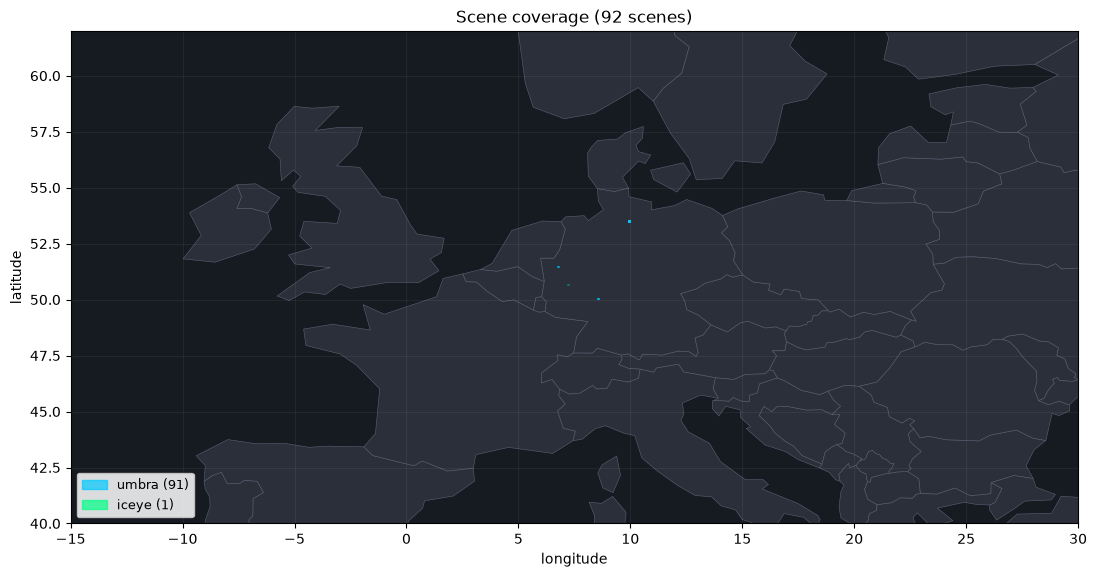

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

scenes.plot_coverage(bbox=(-15, 40, 30, 62))   # zoom to the search area
plt.show()

## Anatomy of a scene

These attributes come from the search index and cost nothing.

In [7]:
s = scenes[0]

print('id       :', s.id)
print('provider :', s.provider)
print('date     :', s.date, '| year:', s.year)
print('mode     :', s.mode)
print('orbit    :', s.orbit, '| look:', s.look)
print('formats  :', s.formats)
print('bbox     :', s.bbox)

id       : ICEYE_U1J05X_20251109T212114Z_6992608_X42_SLP3L
provider : iceye
date     : 2025-11-09 | year: 2025
mode     : spotlight
orbit    : ascending | look: left
formats  : ['GRD', 'SLC', 'CSI', 'VID']
bbox     : [7.1494, 50.6358, 7.2387, 50.6926]


## Lazy loading

Download URLs are **not** in the search index, because including them would make it
far larger. They live in the per-provider files, which the client fetches the first
time you ask for one and then caches.

So the next cell is the slow one. Everything after it is fast.

In [8]:
fmt = s.formats[0]

print('format      :', fmt)
print('download    :', s.url(fmt))
print('sidecar     :', s.metadata_url(fmt))
print('polarization:', s.properties.get('sar:polarizations'))
print('resolution  :', s.properties.get('sar:resolution_range'))

format      : GRD
download    : https://iceye-open-data-catalog.s3.amazonaws.com/data/spot-precise/ICEYE_U1J05X_20251109T212114Z_6992608_X42_SLP3L/ICEYE_U1J05X_20251109T212114Z_6992608_X42_SLP3L_GRD.tif
sidecar     : https://iceye-open-data-catalog.s3.amazonaws.com/data/spot-precise/ICEYE_U1J05X_20251109T212114Z_6992608_X42_SLP3L/ICEYE_U1J05X_20251109T212114Z_6992608_X42_SLP3L_GRD.json
polarization: ['VV']
resolution  : None


## Licence

Scene metadata is **CC-BY 4.0**. When you publish derived work, credit the
originating provider. Imagery is never proxied by this project: every download URL
points at the provider's own storage.

In [9]:
lic = cat.license()
print(lic['license'], '-', lic['license_url'])
print()
print(lic['attribution'])

CC-BY-4.0 - https://creativecommons.org/licenses/by/4.0/

Scene metadata (c) ICEYE, Umbra and Capella, published under their open data programs and licensed CC-BY 4.0. Catalog assembled by open-sar-triad (https://github.com/pmuguda/open-sar-triad) from normalized STAC records maintained by Jack-Hayes/commerical-sar-stac (MIT). When redistributing this data or publishing derived work, credit the originating provider.


---

Next: **02_search_and_download.ipynb**, which covers narrowing a search and
pulling the actual products down.